# Isolation Forest Anomaly Detection on ZTF Transients

Trains an Isolation Forest anomaly detector on reLAISS lightcurve features extracted from ZTF transients.

**Pipeline:**
1. Load reLAISS feature table (with alert-span durations)
2. Apply quality cuts (duration ≤ 200 days, Galactic latitude |b| ≥ 15°)
3. Select lightcurve features (LC only, no host galaxy)
4. Impute missing values with KNN and train Isolation Forest
5. Explore results with PCA
6. Validate on a fresh sample of ALeRCE-classified transients
7. Save model artifacts for downstream LSST scoring

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import dump, load
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from astropy.coordinates import SkyCoord
import astropy.units as u

from alerce.core import Alerce
from relaiss import constants

alerce = Alerce()


## 2. Load data

Load the reLAISS reference catalogue with alert-span durations added.
`reference_20k_with_durations.csv` extends the base `reference_20k.csv` with four
new columns: `antares_duration`, `duration_days`, `antares_oldest_alert`, and
`antares_newest_alert`.

In [2]:
CSV_PATH = "/Users/jennakempster-taylor/re-laiss/data/reference_20k_with_durations.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

# Confirm duration columns are present
duration_cols = ["antares_duration", "duration_days", "antares_newest_alert", "antares_oldest_alert"]
missing_summary = (
    df[duration_cols].isna().sum().to_frame("Missing")
    .assign(Total=len(df))
    .assign(Percent=lambda x: (x["Missing"] / x["Total"] * 100).round(1))
)
print(missing_summary)

# Grab reLAISS feature lists
default_lc_features   = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()
print(f"\nLC features available:   {len(default_lc_features)}")
print(f"Host features available: {len(default_host_features)}")


Loaded 25,515 rows, 462 columns
                      Missing  Total  Percent
antares_duration         3756  25515     14.7
duration_days            3756  25515     14.7
antares_newest_alert       48  25515      0.2
antares_oldest_alert       48  25515      0.2

LC features available:   25
Host features available: 18


## 3. Quality cuts

Two cuts are applied:
- **Duration ≤ 200 days** — removes long-lived AGN/variables unlikely to be supernovae
- **Galactic latitude |b| ≥ 15°** — removes objects near the Galactic plane where
  dust extinction and stellar contamination are high

In [3]:
DURATION_MAX_DAYS = 200
LAT_CUT_DEG       = 15.0

coords = SkyCoord(ra=df["ra"].values * u.deg,
                  dec=df["dec"].values * u.deg,
                  frame="icrs")
b = coords.galactic.b.deg

mask_duration = df["duration_days"] <= DURATION_MAX_DAYS
mask_lat      = np.abs(b) >= LAT_CUT_DEG
mask          = mask_duration & mask_lat

df_cut = df[mask].copy()

print(f"Rows after cuts: {len(df_cut):,} / {len(df):,}")
print(f"  Removed by duration cut:  {(~mask_duration).sum():,}")
print(f"  Removed by galactic cut:  {(~mask_lat).sum():,}")
print(f"  Removed by both:          {(~mask).sum():,}")


Rows after cuts: 17,254 / 25,515
  Removed by duration cut:  6,488
  Removed by galactic cut:  5,857
  Removed by both:          8,261


## 4. Feature selection

Using lightcurve-only features (`USE_HOST = False`) so the model can later be applied
to LSST alerts, which do not have host galaxy photometry available.
Error columns (`*_err`) are excluded as they are not informative for anomaly detection.

In [7]:
USE_HOST = False

def overlap(cols, frame):
    """Return columns that exist in frame and are not error columns."""
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols      = overlap(default_lc_features, df_cut)
host_cols    = overlap(default_host_features, df_cut) if USE_HOST else []
feature_cols = lc_cols + host_cols

print(f"LC features selected:   {len(lc_cols)}")
print(f"Host features selected: {len(host_cols)}")
print(f"Total features:         {len(feature_cols)}")


LC features selected:   25
Host features selected: 0
Total features:         25


## 5. Imputation and model training

Missing values are filled using KNN imputation (k=5) before training.
Isolation Forest grows 300 trees with `contamination='auto'`, which estimates
the anomaly fraction from the data rather than requiring it to be specified.

In [9]:
# Drop non-numeric columns and impute
numeric_feature_cols = [c for c in feature_cols
                        if pd.api.types.is_numeric_dtype(df_cut[c])]
X = df_cut[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)

knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp   = knn_imp.fit_transform(X)
X_imp_df = pd.DataFrame(X_imp, columns=numeric_feature_cols, index=df_cut.index)

print(f"Feature matrix shape: {X_imp.shape}")


Feature matrix shape: (17254, 25)


In [10]:
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)
iso.fit(X_imp)

scores   = iso.decision_function(X_imp)  # higher = more normal
raw_pred = iso.predict(X_imp)            # -1 = anomaly, +1 = normal
anomaly  = (raw_pred == -1).astype(int)  # 1 = anomaly
rank     = pd.Series(scores).rank(method="first", ascending=True).astype(int)

print(f"Estimated anomaly rate: {anomaly.mean():.3f}  ({anomaly.sum()} objects flagged)")


Estimated anomaly rate: 0.042  (729 objects flagged)


In [11]:
threshold_correct = scores[raw_pred == 1].min()
print(f"Correct threshold: {threshold_correct}")

# Also verify it makes sense
print(f"Most anomalous flagged object: {scores[raw_pred == -1].max():.6f}")
print(f"Least anomalous normal object: {scores[raw_pred == 1].min():.6f}")
# These two should be very close together

Correct threshold: 9.234732664842316e-06
Most anomalous flagged object: -0.000042
Least anomalous normal object: 0.000009


In [12]:
print(f"Total objects: {len(scores)}")
print(f"Flagged as anomaly: {(raw_pred == -1).sum()}")
print(f"Flagged as normal: {(raw_pred == 1).sum()}")
print(f"Score range: {scores.min():.6f} to {scores.max():.6f}")
print(f"Score mean: {scores.mean():.6f}")

Total objects: 17254
Flagged as anomaly: 729
Flagged as normal: 16525
Score range: -0.214968 to 0.174140
Score mean: 0.119934


AttributeError: 'numpy.ndarray' object has no attribute 'median'

## 6. Results preview

Top-10 most anomalous objects by Isolation Forest rank.

In [16]:
df_scored = df_cut.copy()
df_scored["iso_score"]   = np.asarray(scores).ravel()
df_scored["iso_anomaly"] = np.asarray(anomaly).ravel()
df_scored["iso_rank"]    = np.asarray(rank).ravel()

context_cols = [c for c in ["t0", "r_duration_above_half_flux", "g_peak_mag",
                             "r_peak_mag", "mean_g-r", "features_valid"]
                if c in df_scored.columns]

preview = df_scored[["ZTFID"] + context_cols + ["iso_score", "iso_anomaly", "iso_rank"]]
display(preview.sort_values("iso_rank").head(10))


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,iso_score,iso_anomaly,iso_rank
10370,ZTF22abewydn,59822.504873,18.979757,14.723200,15.154900,0.778043,False,-0.214968,1,1
1976,ZTF20actzmzp,59180.457222,0.997963,12.346022,12.654753,0.023451,False,-0.199994,1,2
16015,ZTF24aahkzvn,60389.519734,1.007234,16.399099,15.646200,0.219078,False,-0.195116,1,3
3462,ZTF21aanehlz,59269.465845,6.994768,13.308370,13.583603,0.529780,False,-0.191229,1,4
13601,ZTF23aapsuva,60119.405752,118.730058,18.977400,18.754801,0.223114,True,-0.184165,1,5
623,ZTF20aapchqy,58898.530648,121.733056,17.626400,17.099001,0.831728,False,-0.180580,1,6
9391,ZTF22aapkbkl,59751.427049,135.732234,18.993099,18.510201,0.476248,True,-0.172130,1,7
13935,ZTF23aatmqvz,60141.426181,441.989340,20.155300,19.810200,0.543308,True,-0.169166,1,8
8657,ZTF22aajjqti,59707.430162,5.976447,14.233615,14.221217,0.063208,False,-0.168979,1,9
7706,ZTF21acpfndw,59531.487442,0.101817,15.838621,15.937201,0.057640,False,-0.168397,1,10


## 7. PCA exploration

PCA is computed on the standardised imputed feature matrix to visualise how
anomalies are distributed in reduced feature space.

Components needed for 90% variance: 15


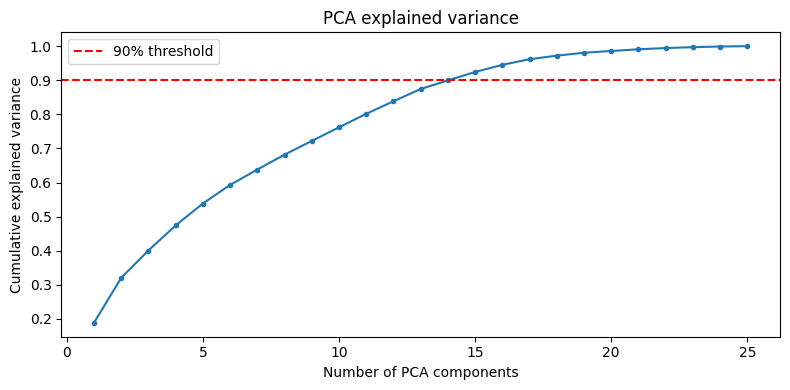

In [18]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Cumulative explained variance
pca_full  = PCA().fit(X_scaled)
cum_var   = np.cumsum(pca_full.explained_variance_ratio_)
n_for_90  = np.searchsorted(cum_var, 0.90) + 1
print(f"Components needed for 90% variance: {n_for_90}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
ax.axhline(0.90, color="red", linestyle="--", label="90% threshold")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance")
ax.legend()
plt.tight_layout()
plt.show()


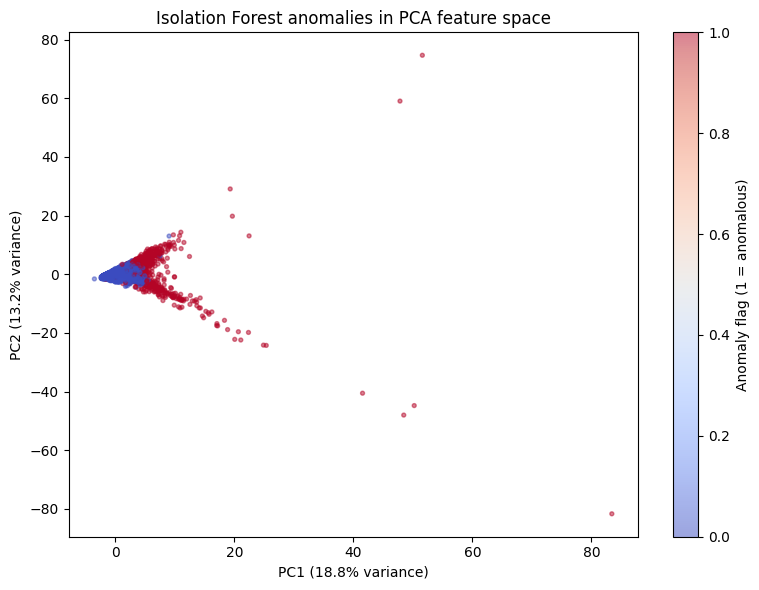

In [20]:
# 2D PCA coloured by anomaly flag
pca2  = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

colors = df_scored["iso_anomaly"].values

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors, cmap="coolwarm", alpha=0.5, s=8)
plt.colorbar(sc, ax=ax, label="Anomaly flag (1 = anomalous)")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Isolation Forest anomalies in PCA feature space")
plt.tight_layout()
plt.show()


In [22]:
# Top features driving PC1
pca_loadings = pd.DataFrame(
    pca2.components_,
    columns=numeric_feature_cols,
    index=["PC1", "PC2"]
)
print("Top 10 features by |PC1| loading:")
display(pca_loadings.T["PC1"].abs().sort_values(ascending=False).head(10).to_frame())


Top 10 features by |PC1| loading:


,PC1
r_mean_rolling_variance,0.327013
g_mean_rolling_variance,0.316223
r_amplitude,0.313235
r_max_rolling_variance,0.307702
g_amplitude,0.307539
g_max_rolling_variance,0.307071
r_duration_above_half_flux,0.263583
g_duration_above_half_flux,0.245111
g_decline_time,0.224963
r_decline_time,0.219107


In [24]:
pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [kaleido]m4/6 [pytest-timeout]
Note: you may need to restart the kernel to use updated packages.


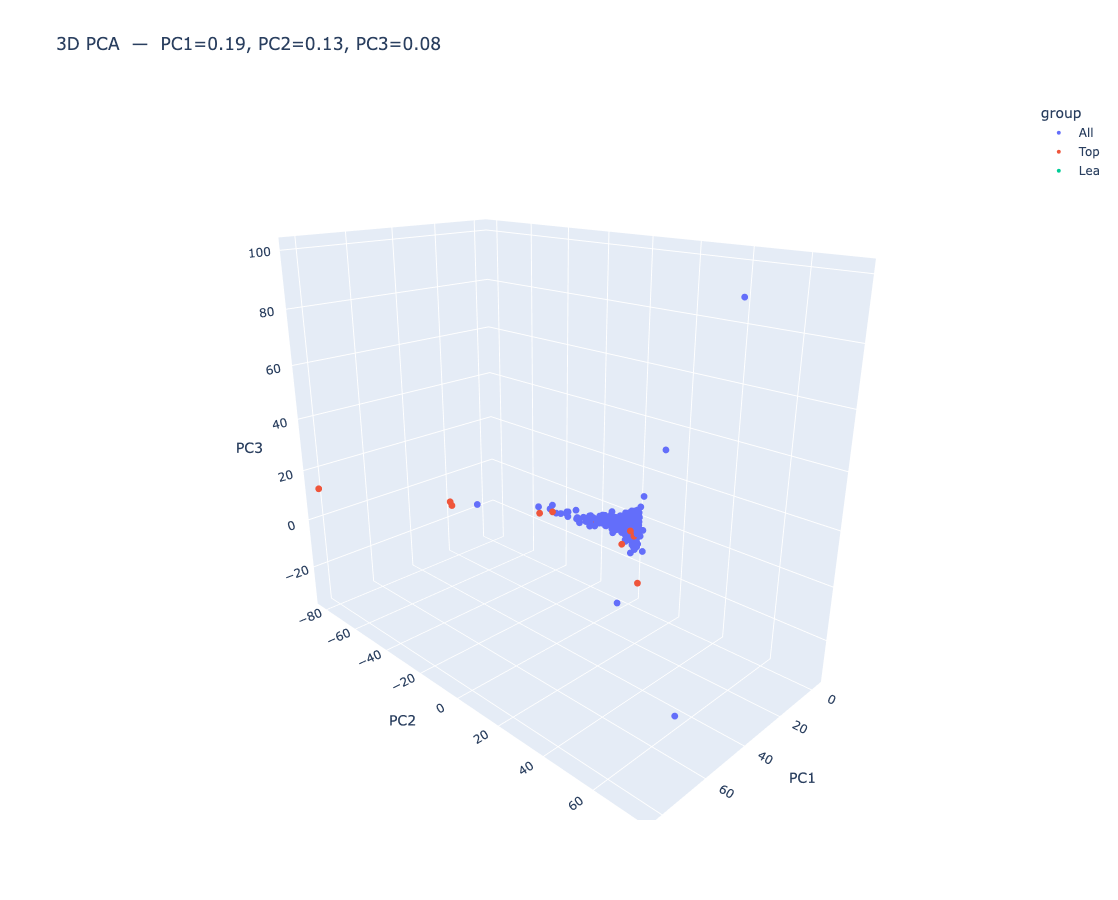

In [26]:
# Interactive 3D PCA
import plotly.express as px

pca3   = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
evr    = pca3.explained_variance_ratio_

plot_df = df_scored[["ZTFID", "iso_rank", "iso_anomaly"]].copy()
plot_df["PC1"] = X_pca3[:, 0]
plot_df["PC2"] = X_pca3[:, 1]
plot_df["PC3"] = X_pca3[:, 2]

top10_idx    = plot_df.sort_values("iso_rank").head(10).index
bottom10_idx = plot_df.sort_values("iso_rank").tail(10).index
group        = np.full(len(plot_df), "All")
group[plot_df.index.isin(top10_idx)]    = "Top-10 anomalies"
group[plot_df.index.isin(bottom10_idx)] = "Least anomalous 10"
plot_df["group"] = group

fig = px.scatter_3d(
    plot_df, x="PC1", y="PC2", z="PC3",
    color="group",
    hover_name="ZTFID",
    hover_data=["iso_rank", "iso_anomaly"],
    title=(f"3D PCA  —  PC1={evr[0]:.2f}, PC2={evr[1]:.2f}, PC3={evr[2]:.2f}")
)
fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=0.8)  
    )
)

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2", 
        zaxis_title="PC3"
    )
)

fig.write_image("pca_3d.png", scale=2)  
fig.show()


## 8. Save model artifacts

Save the fitted imputer and model together so they can be loaded for inference
on new objects (LSST or ALeRCE) without retraining.

In [33]:
ARTIFACTS_PATH = "iforest_artifacts.joblib"

dump(
    {
        "iso": iso,
        "knn_imp": knn_imp,
        "numeric_feature_cols": numeric_feature_cols
    },
    ARTIFACTS_PATH
)
print(f"Saved: {ARTIFACTS_PATH}")
print(f"  Features: {len(numeric_feature_cols)}")
print(f"  Feature list: {numeric_feature_cols}")


Saved: iforest_artifacts.joblib
  Features: 25
  Feature list: ['g_peak_time', 'r_peak_time', 'g_rise_time', 'g_decline_time', 'r_rise_time', 'r_decline_time', 'g_duration_above_half_flux', 'r_duration_above_half_flux', 'g_amplitude', 'r_amplitude', 'g_skewness', 'r_skewness', 'g_beyond_2sigma', 'r_beyond_2sigma', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate', 'g_max_rolling_variance', 'r_max_rolling_variance', 'g_mean_rolling_variance', 'r_mean_rolling_variance', 'g_rise_local_curvature', 'g_decline_local_curvature', 'r_rise_local_curvature', 'r_decline_local_curvature']


## 9. Validation on ALeRCE transients

As a sanity check, the trained model is applied to a fresh sample of recent
ZTF transients fetched from the ALeRCE broker. These objects were not seen
during training, so this tests whether the anomaly scores generalise.

### 9.1 Fetch a sample of recent transients

In [40]:
# Load artifacts 
art = load(ARTIFACTS_PATH)
iso_val              = art["iso"]
knn_imp_val          = art["knn_imp"]
numeric_feature_cols = art["numeric_feature_cols"]

# Fetch up to 1000 recent objects classified as Transient by ALeRCE lc_classifier
objs_top = alerce.query_objects(
    classifier="lc_classifier_top",
    class_name="Transient",
    probability=0.7,
    page_size=1000,
    order_by="lastmjd",
    order_mode="DESC",
    format="pandas"
).drop_duplicates("oid")

oids = objs_top["oid"].tolist()
print(f"Fetched {len(oids)} transient candidates from ALeRCE")


NameError: name 'ARTIFACTS_PATH' is not defined

### 9.2 Filter to likely SNe using stamp classifier

In [55]:
# Cross-check with stamp classifier to keep high-confidence SNe
probs_list = []
for oid in tqdm(oids, desc="Fetching probabilities"):
    try:
        p = alerce.query_probabilities(oid, format="pandas", survey="ztf")
        if p is not None and not p.empty:
            p["oid"] = oid
            probs_list.append(p)
    except Exception as e:
        print(f"Failed for {oid}: {e}")

probs_stamp = pd.concat(probs_list, ignore_index=True) if probs_list else pd.DataFrame()

wide = probs_stamp.pivot_table(
    index="oid", columns="class_name", values="probability", aggfunc="max"
).fillna(0.0)

if "SN" not in wide.columns:
    wide["SN"] = 0.0

cand    = wide[wide["SN"] >= 0.7].index
sn_objs = objs_top[objs_top["oid"].isin(cand)].copy()
oids    = sn_objs["oid"].tolist()

print(f"Total Transients: {len(objs_top)}  |  Likely SNe (stamp P ≥ 0.7): {len(sn_objs)}")
sn_objs.head()


Fetching probabilities: 100%|███████████████| 1000/1000 [14:55<00:00,  1.12it/s]


Total Transients: 1000  |  Likely SNe (stamp P ≥ 0.7): 186


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
9,ZTF18aczvwdh,851,1559,58132.229306,61102.256574,True,False,495,None,None,...,61102.256574,2379.791968,88.433938,14.208530,0.003501,0.003394,Transient,lc_classifier_top,0.744,27.5.7a32.dev1
12,ZTF20aaawwkl,979,1980,58513.380127,61102.234931,True,False,562,None,None,...,61102.234931,2252.780903,152.560802,23.108918,0.003126,0.002875,Transient,lc_classifier_top,0.738,27.5.7a32.dev1
18,ZTF20acsaaad,22,1161,59173.316748,61102.195428,False,False,22,None,None,...,61102.195428,1928.878681,75.120779,25.202233,0.017206,0.015568,Transient,lc_classifier_top,0.944,27.5.7a32.dev1
21,ZTF20accmutv,484,1995,58439.385914,61102.169178,False,False,165,None,None,...,61102.169178,1975.685058,126.099389,-3.488631,0.003172,0.003167,Transient,lc_classifier_top,0.988,27.5.7a32.dev1
28,ZTF20acqgklx,207,1572,58743.498623,61102.141470,True,False,71,None,None,...,61102.141470,1937.810069,76.633692,7.760104,0.003332,0.003301,Transient,lc_classifier_top,0.998,27.5.7a32.dev1


### 9.3 Fetch ALeRCE features and score

In [36]:
def fetch_features(oids, keep_placeholders=True):
    """Fetch ALeRCE feature tables for a list of OIDs and pivot to wide format."""
    rows, bad = [], []
    for oid in tqdm(oids, desc="Fetching ALeRCE features"):
        try:
            f = alerce.query_features(oid, format="pandas")
            if (f is None) or f.empty or not {"oid", "name", "value"}.issubset(f.columns):
                if keep_placeholders:
                    rows.append(pd.DataFrame(index=pd.Index([oid], name="oid")))
                else:
                    bad.append((oid, "empty-or-missing-cols"))
                continue
            fw = f.pivot_table(index="oid", columns="name", values="value", aggfunc="first")
            rows.append(fw)
        except Exception as e:
            if keep_placeholders:
                rows.append(pd.DataFrame(index=pd.Index([oid], name="oid")))
            else:
                bad.append((oid, str(e)))
    out = pd.concat(rows, axis=0) if rows else pd.DataFrame()
    return out, bad


df_new, bad = fetch_features(oids, keep_placeholders=True)

# Align columns to training feature order, filling any missing with NaN
for c in numeric_feature_cols:
    if c not in df_new.columns:
        df_new[c] = np.nan
X_new = df_new[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)

print(f"Rows fetched: {len(df_new)}  |  Failed: {len(bad)}")


NameError: name 'oids' is not defined

In [58]:
# Score using training imputer and model
X_new_imp  = knn_imp_val.transform(X_new)
scores_new = iso_val.decision_function(X_new_imp)
pred_new   = iso_val.predict(X_new_imp)
anom_new   = (pred_new == -1).astype(int)

# Rank and attach metadata
res = pd.DataFrame({
    "oid":         df_new.index,
    "iso_score":   scores_new,
    "iso_anomaly": anom_new
}).reset_index(drop=True)

res["iso_rank"] = res["iso_score"].rank(method="first", ascending=True).astype(int)

keep_cols = [c for c in ["oid", "meanra", "meandec", "ndet", "firstmjd", "lastmjd", "class_name"]
             if c in sn_objs.columns]
res = res.merge(sn_objs[keep_cols], on="oid", how="left")

print(f"Anomaly rate on ALeRCE sample: {anom_new.mean():.3f}  ({anom_new.sum()} flagged)")


Anomaly rate on ALeRCE sample: 0.000  (0 flagged)


### 9.4 Top anomalies in ALeRCE validation sample

In [59]:
res.sort_values("iso_rank").to_csv("alerce_iforest_scored.csv", index=False)
print("Saved: alerce_iforest_scored.csv")

display(res.sort_values("iso_rank").head(10))


Saved: alerce_iforest_scored.csv


,oid,iso_score,iso_anomaly,iso_rank,meanra,meandec,ndet,firstmjd,lastmjd
0,ZTF18aczvwdh,0.064724,0,1,88.433938,14.208530,495,58722.464607,61102.256574
1,ZTF20aaawwkl,0.064724,0,2,152.560802,23.108918,562,58849.454028,61102.234931
2,ZTF20acsaaad,0.064724,0,3,75.120779,25.202233,22,59173.316748,61102.195428
3,ZTF20accmutv,0.064724,0,4,126.099389,-3.488631,165,59126.484120,61102.169178
4,ZTF20acqgklx,0.064724,0,5,76.633692,7.760104,71,59164.331401,61102.141470
5,ZTF19abwsecm,0.064724,0,6,49.599160,-1.930455,31,58725.461806,61102.131100
6,ZTF20abyylgi,0.064724,0,7,59.544606,-8.816906,129,59108.480498,61102.130162
7,ZTF18admikzo,0.064724,0,8,287.130284,-0.415087,245,59733.354375,61101.545880
8,ZTF18abginsq,0.064724,0,9,289.620914,3.484161,795,58307.354224,61101.545880
9,ZTF18abfjqtf,0.064724,0,10,283.776545,0.616290,917,58307.376956,61101.544456


In [32]:

sn_objs.to_csv("alerce_sn_objs.csv")

NameError: name 'df_new' is not defined

In [42]:
print(numeric_feature_cols[:10])

['g_peak_time', 'r_peak_time', 'g_rise_time', 'g_decline_time', 'r_rise_time', 'r_decline_time', 'g_duration_above_half_flux', 'r_duration_above_half_flux', 'g_amplitude', 'r_amplitude']
